# Notebook 2: TFLite Inference, Automatic Threshold Binning & Evaluation

This notebook executes zero-shot inference on the prepared PVS central dataset using our deployed TensorFlow Lite model (`iri_background_model.tflite`). We replicate the exact preprocessing pipeline from Section 7 of our training pipeline:
- **Sliding Spatial Window:** $100\text{ m}$ window size with $10\text{ m}$ step size ($90\%$ overlap).
- **Monotonic Distance & Dead-Stop Override:** Monotonic odometry perturbation (`cumsum() + arange * 1e-4`) and baseline assignment ($v < 0.5\text{ km/h} \to \text{IRI} = 1.5\text{ m/km}$).
- **Spatial Resampling:** Interpolation to `FINAL_STEPS = 400` points ($0.25\text{ m}$ resolution).
- **Physics Velocity Normalization:** $a_z \leftarrow a_z \cdot (22.22 / v_{\text{safe}})^2$ to normalize all vibrations to a reference speed of $80\text{ km/h}$.
- **Contextual Branch:** 13-dimensional statistical feature vector (mean/std speed, RMS, crest factor, MCR, P2P, and PSD frequency band ratios).
- **Calibration LUT:** Piecewise linear post-processing via `mobile_calibration_lut.json`.

### Axis Calibration Toggles
In simulation training data, vertical gravity averages around $-9.8\text{ m/s}^2$, whereas in PVS vehicle sensor logs it averages around $+9.8\text{ m/s}^2$. Additionally, smartphone mounting orientations may rotate horizontal axes by $90^\circ$. We provide toggle variables (`INVERT_AZ` and `SWAP_AX_AY`) at the top of the notebook to seamlessly align physical sensor coordinate frames with training assumptions.

### Automated Threshold Binning & Trip-Wise Isolation
To evaluate our continuous IRI predictions against PVS categorical ground truth (`0 = Good`, `1 = Regular`, `2 = Bad`), we perform an automated 2D grid search over boundary thresholds $(T_1, T_2)$ with $0.1\text{ m/km}$ spacing across all trips combined, finding the exact cutoffs that maximize macro F1-score. Finally, we compute and export confusion matrices both globally across all 9 trips and individually for each trip (`PVS 1` through `PVS 9`) to retain full visibility into route-specific generalization.


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy.interpolate import interp1d
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix, classification_report, balanced_accuracy_score

# --- CONFIGURATION & PATHS ---
MODEL_PATH = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\iri_background_model.tflite"
LUT_PATH = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\mobile_calibration_lut.json"

DATA_DIR = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data"
OUTPUT_DIR = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- AXIS CALIBRATION TOGGLES ---
# In training simulation data, az averages around -9.8 m/s^2, whereas in PVS physical logs it averages around +9.8 m/s^2.
INVERT_AZ = True 
# Toggle to swap horizontal axes (ax <-> ay and wx <-> wy) if PVS sensor orientation is rotated 90 degrees relative to simulation
SWAP_AX_AY = True 
# Toggle to convert gyroscopes from deg/s to rad/s (set to True if loading raw deg/s data directly into Notebook 2)
CONVERT_GYRO_DEG_TO_RAD = False 

# --- INFERENCE PARAMETERS (Exact Model 3 Specs) ---
WINDOW_SIZE_M = 100.0
STEP_SIZE_M = 10.0
FINAL_STEPS = 400
FEATURES = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']

print(f"[*] TFLite Model Path: {MODEL_PATH}")
print(f"[*] Calibration LUT Path: {LUT_PATH}")
print(f"[*] Axis Calibration -> INVERT_AZ: {INVERT_AZ} | SWAP_AX_AY: {SWAP_AX_AY} | CONVERT_GYRO_DEG_TO_RAD: {CONVERT_GYRO_DEG_TO_RAD}")


[*] TFLite Model Path: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\iri_background_model.tflite
[*] Calibration LUT Path: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\mobile_calibration_lut.json
[*] Axis Calibration -> INVERT_AZ: True | SWAP_AX_AY: True | CONVERT_GYRO_DEG_TO_RAD: False


In [2]:
# --- CONTEXT FEATURE EXTRACTION (Matches Model 3) ---
def extract_context_features(raw_data_window, speed_array):
    ax, ay, az, wx, wy, wz = [raw_data_window[:, i] for i in range(6)]
    N = len(az)
    
    speed_mean = np.mean(speed_array)
    speed_std = np.std(speed_array)
    
    rms_az = np.sqrt(np.mean(az**2))
    rms_ay = np.sqrt(np.mean(ay**2))
    var_az = np.var(az)
    crest_factor_az = np.max(np.abs(az)) / (rms_az + 1e-6)
    
    zero_crossings_az = len(np.where(np.diff(np.sign(az)))[0])
    mcr_az = zero_crossings_az / N
    p2p_az = np.max(az) - np.min(az)
    
    rms_wz = np.sqrt(np.mean(wz**2))
    rms_wy = np.sqrt(np.mean(wy**2))
    mean_abs_ax = np.mean(np.abs(ax))
    
    # Pseudo-Spectral features
    fft_vals = np.fft.rfft(az)
    psd = np.abs(fft_vals)**2
    freqs_spatial = np.fft.rfftfreq(N, d=0.25)
    
    if speed_mean > 0:
        freqs_temporal = freqs_spatial * speed_mean
        band_1_4 = np.sum(psd[(freqs_temporal >= 1.0) & (freqs_temporal <= 4.0)])
        band_4_15 = np.sum(psd[(freqs_temporal > 4.0) & (freqs_temporal <= 15.0)])
        total_energy = np.sum(psd) + 1e-6
        
        energy_ratio_1_4 = band_1_4 / total_energy
        energy_ratio_4_15 = band_4_15 / total_energy
    else:
        energy_ratio_1_4, energy_ratio_4_15 = 0.0, 0.0

    return np.array([
        speed_mean, speed_std, rms_az, rms_ay, var_az, crest_factor_az,
        mcr_az, p2p_az, rms_wz, rms_wy, mean_abs_ax, 
        energy_ratio_1_4, energy_ratio_4_15
    ], dtype=np.float32)

# --- LUT CALIBRATION ---
def calibrate_iri(raw_iri, lut_path=LUT_PATH):
    if not os.path.exists(lut_path):
        return raw_iri
    with open(lut_path, 'r') as f:
        lut = json.load(f)
    return float(np.interp(raw_iri, lut['x_raw'], lut['y_calibrated']))


In [3]:
# --- WINDOWED TFLITE INFERENCE ENGINE ---
def run_trip_inference(trip_id, interpreter, raw_input_idx, ctx_input_idx, output_idx):
    csv_path = os.path.join(DATA_DIR, f"PVS_{trip_id}_central.csv")
    if not os.path.exists(csv_path):
        print(f"[!] Missing {csv_path}")
        return None, None
        
    print(f"[+] Running TFLite Inference on PVS {trip_id}...")
    df = pd.read_csv(csv_path)
    
    # Time and odometry calculation
    df['dt'] = df['timestamp'].diff().fillna(0.01)
    df['dt'] = np.where(df['dt'] <= 0, 0.01, df['dt'])
    df['dx'] = df['speed'] * df['dt']
    df['cumulative_distance'] = df['dx'].cumsum() + (np.arange(len(df)) * 1e-4)
    
    max_dist = df['cumulative_distance'].max()
    windows = []
    
    # Sliding spatial window
    for start_dist in np.arange(0, max_dist - WINDOW_SIZE_M, STEP_SIZE_M):
        end_dist = start_dist + WINDOW_SIZE_M
        patch = df[(df['cumulative_distance'] >= start_dist) & (df['cumulative_distance'] < end_dist)]
        
        if len(patch) < 20:
            continue
            
        avg_speed_ms = patch['speed'].mean()
        avg_speed_kmh = avg_speed_ms * 3.6
        
        # Dead stop override
        if avg_speed_kmh < 0.5:
            final_iri = 1.5
        else:
            # Extract features and apply axis toggles
            patch_dict = {}
            for feat in FEATURES:
                patch_dict[feat] = patch[feat].values.copy()
                
            if INVERT_AZ:
                patch_dict['az'] = -patch_dict['az']
            if SWAP_AX_AY:
                patch_dict['ax'], patch_dict['ay'] = patch_dict['ay'].copy(), patch_dict['ax'].copy()
                patch_dict['wx'], patch_dict['wy'] = patch_dict['wy'].copy(), patch_dict['wx'].copy()
            if CONVERT_GYRO_DEG_TO_RAD:
                for g_col in ['wx', 'wy', 'wz']:
                    patch_dict[g_col] = patch_dict[g_col] * (np.pi / 180.0)
                
            # Distance domain resampling
            fixed_spatial_grid = np.linspace(start_dist, end_dist, FINAL_STEPS)
            fixed_patch_features = []
            for feat in FEATURES:
                spatial_fix = interp1d(
                    patch['cumulative_distance'], patch_dict[feat],
                    kind='linear', bounds_error=False,
                    fill_value=(patch_dict[feat][0], patch_dict[feat][-1])
                )
                fixed_patch_features.append(spatial_fix(fixed_spatial_grid))
                
            spatial_speed = interp1d(
                patch['cumulative_distance'], patch['speed'],
                kind='linear', bounds_error=False,
                fill_value=(patch['speed'].iloc[0], patch['speed'].iloc[-1])
            )(fixed_spatial_grid)
            
            X_raw_filtered = np.column_stack(fixed_patch_features).astype(np.float32)
            
            # Physics speed normalization (80 km/h = 22.22 m/s)
            az_idx = FEATURES.index('az')
            v_safe = np.maximum(spatial_speed, 5.0)
            X_raw_filtered[:, az_idx] = X_raw_filtered[:, az_idx] * ((22.22 / v_safe) ** 2)
            
            X_ctx = extract_context_features(X_raw_filtered, spatial_speed)
            
            X_raw_batch = np.expand_dims(X_raw_filtered, axis=0)
            X_ctx_batch = np.expand_dims(X_ctx, axis=0)
            
            interpreter.set_tensor(raw_input_idx, X_raw_batch)
            interpreter.set_tensor(ctx_input_idx, X_ctx_batch)
            interpreter.invoke()
            
            pred_log = interpreter.get_tensor(output_idx)[0][0]
            pred_iri_raw = np.expm1(pred_log)
            final_iri = calibrate_iri(pred_iri_raw)
            
        # Ground truth window aggregation (Mode / Max severity in window)
        win_label_mid = int(patch['label_mid'].mode()[0]) if not patch['label_mid'].mode().empty else int(patch['label_mid'].max())
        
        # Aggregate surface metadata
        win_meta = {
            'trip_id': f"PVS {trip_id}",
            'start_dist': start_dist,
            'end_dist': end_dist,
            'mean_lat': patch['latitude'].mean(),
            'mean_lon': patch['longitude'].mean(),
            'mean_speed_kmh': avg_speed_kmh,
            'predicted_iri': final_iri,
            'label_mid': win_label_mid,
            'paved_road': int(patch['paved_road'].max()),
            'unpaved_road': int(patch['unpaved_road'].max()),
            'dirt_road': int(patch['dirt_road'].max()),
            'cobblestone_road': int(patch['cobblestone_road'].max()),
            'asphalt_road': int(patch['asphalt_road'].max()),
            'speed_bump_asphalt': int(patch['speed_bump_asphalt'].max()),
            'speed_bump_cobblestone': int(patch['speed_bump_cobblestone'].max())
        }
        windows.append(win_meta)
        
    df_win = pd.DataFrame(windows)
    
    # Map predictions back to raw timestamp CSV for completeness
    if len(df_win) > 0:
        interp_pred = interp1d(
            df_win['start_dist'] + WINDOW_SIZE_M/2.0, df_win['predicted_iri'],
            kind='nearest', bounds_error=False,
            fill_value=(df_win['predicted_iri'].iloc[0], df_win['predicted_iri'].iloc[-1])
        )
        df['predicted_iri'] = interp_pred(df['cumulative_distance'])
    else:
        df['predicted_iri'] = np.nan
        
    out_csv = os.path.join(DATA_DIR, f"PVS_{trip_id}_with_predictions.csv")
    df.to_csv(out_csv, index=False)
    print(f"    [✔] Extracted {len(df_win):,} spatial windows | Saved raw predictions to {out_csv}")
    
    return df_win, df


In [4]:
# --- EXECUTE INFERENCE ACROSS ALL 9 TRIPS ---
print("[+] Allocating TFLite Interpreter...")
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

raw_input_idx = next(i['index'] for i in input_details if len(i['shape']) == 3)
ctx_input_idx = next(i['index'] for i in input_details if len(i['shape']) == 2)
output_idx = output_details[0]['index']

all_trip_windows = {}
combined_windows_list = []

for i in range(1, 10):
    df_win, df_raw = run_trip_inference(i, interpreter, raw_input_idx, ctx_input_idx, output_idx)
    if df_win is not None and len(df_win) > 0:
        all_trip_windows[f"PVS {i}"] = df_win
        combined_windows_list.append(df_win)

df_all_windows = pd.concat(combined_windows_list, ignore_index=True)
combined_csv_path = os.path.join(OUTPUT_DIR, "all_trips_windowed_evaluation.csv")
df_all_windows.to_csv(combined_csv_path, index=False)
print(f"\n[✔] Completed inference on {len(df_all_windows):,} total spatial windows across all trips.")
print(f"[✔] Exported combined window dataset to: {combined_csv_path}")


[+] Allocating TFLite Interpreter...
[+] Running TFLite Inference on PVS 1...
    [✔] Extracted 1,368 spatial windows | Saved raw predictions to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data\PVS_1_with_predictions.csv
[+] Running TFLite Inference on PVS 2...
    [✔] Extracted 1,144 spatial windows | Saved raw predictions to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data\PVS_2_with_predictions.csv
[+] Running TFLite Inference on PVS 3...
    [✔] Extracted 1,060 spatial windows | Saved raw predictions to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data\PVS_3_with_predictions.csv
[+] Running TFLite Inference on PVS 4...
    [✔] Extracted 1,368 spatial windows | Saved raw predictions to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data\PVS_4_with_predictions.csv
[+] Running TFLite Inference on PVS 5...
    [✔] Extracted 1,145 spatial windows | Saved raw predictions to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\data\PVS_5_with_predictions.cs

[+] Running 2D grid search over (T1, T2) boundary thresholds optimizing for: balanced_accuracy...

[★] OPTIMAL THRESHOLDS FOUND (balanced_accuracy) -> T1 (Good/Regular): 3.80 m/km | T2 (Regular/Bad): 11.70 m/km
[★] Maximum balanced_accuracy: 0.6065 | Associated Macro F1: 0.5684 | Balanced Accuracy: 0.6065
[✔] Exported optimal thresholds to: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\optimal_thresholds.json


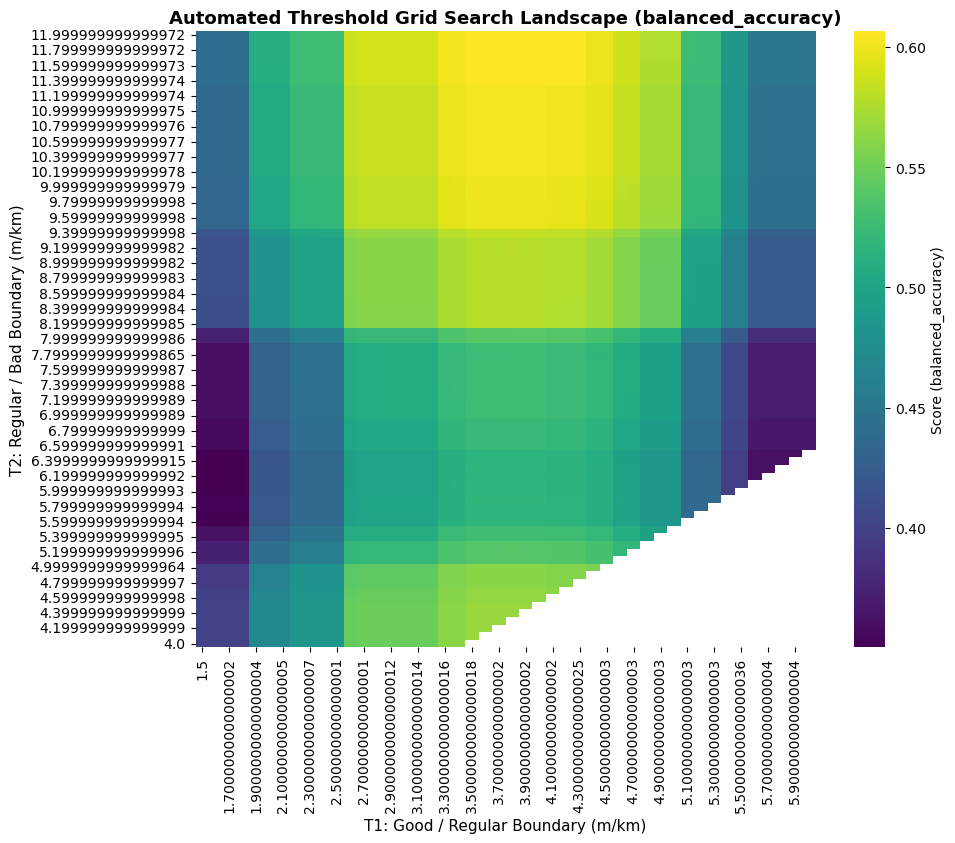

[✔] Saved grid search heatmap to: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\threshold_grid_search_heatmap.png


In [5]:
# --- AUTOMATED 2D GRID SEARCH FOR OPTIMAL IRI THRESHOLDS (0.1 SPACING) ---
# Choose optimization metric:
# 'balanced_accuracy' -> Maximizes average diagonal percentage (recall across Good, Regular, Bad). Best for preventing 0 predictions on minority Bad class!
# 'macro_f1_constrained' -> Maximizes Macro F1 subject to min recall >= 10% for every class.
# 'macro_f1' -> Standard unweighted Macro F1.
OPTIMIZE_METRIC = 'balanced_accuracy'

print(f"[+] Running 2D grid search over (T1, T2) boundary thresholds optimizing for: {OPTIMIZE_METRIC}...")

y_true_all = df_all_windows['label_mid'].values
iri_all = df_all_windows['predicted_iri'].values

t1_range = np.arange(1.5, 6.1, 0.1)
t2_range = np.arange(4.0, 12.1, 0.1)

best_score = -1.0
best_f1 = 0.0
best_bal_acc = 0.0
best_t1, best_t2 = 3.5, 7.0
grid_results = []

for t1 in t1_range:
    for t2 in t2_range:
        if t2 <= t1 + 0.5:
            continue
        # Classify: < t1 -> 0 (Good), t1..t2 -> 1 (Regular), >= t2 -> 2 (Bad)
        y_pred = np.zeros_like(iri_all, dtype=np.int32)
        y_pred[(iri_all >= t1) & (iri_all < t2)] = 1
        y_pred[iri_all >= t2] = 2
        
        macro_f1 = f1_score(y_true_all, y_pred, average='macro', zero_division=0)
        bal_acc = balanced_accuracy_score(y_true_all, y_pred)
        
        if OPTIMIZE_METRIC == 'balanced_accuracy':
            score = bal_acc
        elif OPTIMIZE_METRIC == 'macro_f1_constrained':
            recalls = precision_recall_fscore_support(y_true_all, y_pred, average=None, zero_division=0)[1]
            score = macro_f1 if np.all(recalls >= 0.10) else 0.0
        else:
            score = macro_f1
            
        grid_results.append({'T1': t1, 'T2': t2, 'Macro_F1': macro_f1, 'Balanced_Accuracy': bal_acc, 'Score': score})
        
        if score > best_score:
            best_score = score
            best_f1 = macro_f1
            best_bal_acc = bal_acc
            best_t1, best_t2 = t1, t2

df_grid = pd.DataFrame(grid_results)
print(f"\n[★] OPTIMAL THRESHOLDS FOUND ({OPTIMIZE_METRIC}) -> T1 (Good/Regular): {best_t1:.2f} m/km | T2 (Regular/Bad): {best_t2:.2f} m/km")
print(f"[★] Maximum {OPTIMIZE_METRIC}: {best_score:.4f} | Associated Macro F1: {best_f1:.4f} | Balanced Accuracy: {best_bal_acc:.4f}")

# Save optimal thresholds to JSON for mapping notebook
opt_thresh_file = os.path.join(OUTPUT_DIR, "optimal_thresholds.json")
with open(opt_thresh_file, 'w') as f:
    json.dump({'T1': round(float(best_t1), 2), 'T2': round(float(best_t2), 2), 'best_macro_f1': round(float(best_f1), 4), 'best_bal_acc': round(float(best_bal_acc), 4), 'metric': OPTIMIZE_METRIC}, f, indent=2)
print(f"[✔] Exported optimal thresholds to: {opt_thresh_file}")

# --- PLOT GRID SEARCH HEATMAP ---
plt.figure(figsize=(10, 8))
pivot_grid = df_grid.pivot(index='T2', columns='T1', values='Score')
pivot_grid = pivot_grid.sort_index(ascending=False)
sns.heatmap(pivot_grid, cmap='viridis', cbar_kws={'label': f'Score ({OPTIMIZE_METRIC})'})
plt.title(f"Automated Threshold Grid Search Landscape ({OPTIMIZE_METRIC})", fontsize=13, fontweight='bold')
plt.xlabel("T1: Good / Regular Boundary (m/km)", fontsize=11)
plt.ylabel("T2: Regular / Bad Boundary (m/km)", fontsize=11)
grid_plot_path = os.path.join(FIGURES_DIR, "threshold_grid_search_heatmap.png")
plt.savefig(grid_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[✔] Saved grid search heatmap to: {grid_plot_path}")



GLOBAL COMBINED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Good (0)     0.9491    0.8989    0.9233      7080
 Regular (1)     0.6796    0.9205    0.7819      2894
     Bad (2)     0.0000    0.0000    0.0000       742

    accuracy                         0.8425     10716
   macro avg     0.5429    0.6065    0.5684     10716
weighted avg     0.8106    0.8425    0.8212     10716



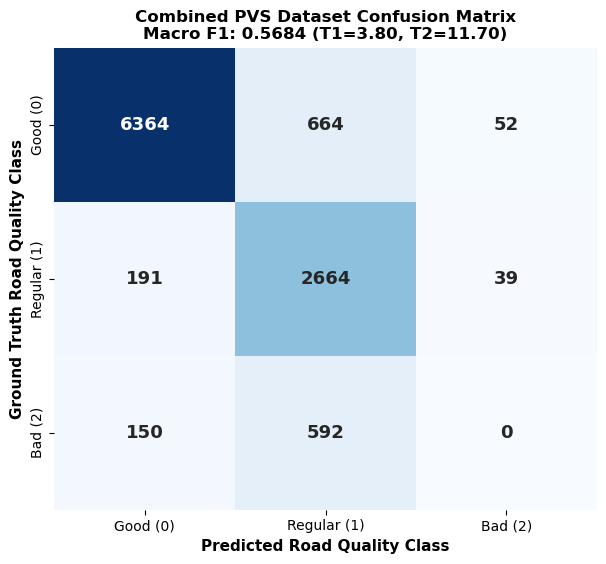

[✔] Exported combined confusion matrix to: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\combined_confusion_matrix.png

TRIP-WISE EVALUATION & CONFUSION MATRICES
    [✔] Exported PVS 1 confusion matrix -> D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\trip_1_confusion_matrix.png (Macro F1: 0.5882)
    [✔] Exported PVS 2 confusion matrix -> D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\trip_2_confusion_matrix.png (Macro F1: 0.5386)
    [✔] Exported PVS 3 confusion matrix -> D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\trip_3_confusion_matrix.png (Macro F1: 0.6060)
    [✔] Exported PVS 4 confusion matrix -> D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\trip_4_confusion_matrix.png (Macro F1: 0.5806)
    [✔] Exported PVS 5 confusion matrix -> D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\review_work\outputs\figures\trip_5_confusion_matrix.png (Macro F1: 0.4958)
    [✔] Exported PVS

,Scope,Samples,Macro_Precision,Macro_Recall,Macro_F1,Accuracy
0,All Trips Combined,10716,0.5429,0.6065,0.5684,0.8425
1,PVS 1,1368,0.5677,0.6223,0.5882,0.8662
2,PVS 2,1144,0.5000,0.6176,0.5386,0.8094
3,PVS 3,1060,0.5963,0.6189,0.6060,0.9151
4,PVS 4,1368,0.5627,0.6098,0.5806,0.8567
5,PVS 5,1145,0.4593,0.5387,0.4958,0.7406
6,PVS 6,1059,0.5505,0.5572,0.5536,0.8395
7,PVS 7,1366,0.5965,0.6196,0.6035,0.8946
8,PVS 8,1145,0.4625,0.6112,0.4995,0.7581
9,PVS 9,1061,0.5805,0.6221,0.5963,0.8935


In [6]:
# --- TRIP-WISE & GLOBAL EVALUATION REPORTS ---
def classify_iri(iri_vals, t1=best_t1, t2=best_t2):
    preds = np.zeros_like(iri_vals, dtype=np.int32)
    preds[(iri_vals >= t1) & (iri_vals < t2)] = 1
    preds[iri_vals >= t2] = 2
    return preds

class_names = ['Good (0)', 'Regular (1)', 'Bad (2)']
score_report_rows = []

print("\n" + "="*80)
print("GLOBAL COMBINED CLASSIFICATION REPORT")
print("="*80)
y_pred_all = classify_iri(df_all_windows['predicted_iri'].values)
print(classification_report(y_true_all, y_pred_all, target_names=class_names, digits=4))

# Plot Combined Confusion Matrix
plt.figure(figsize=(7, 6))
cm_all = confusion_matrix(y_true_all, y_pred_all)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title(f"Combined PVS Dataset Confusion Matrix\nMacro F1: {best_f1:.4f} (T1={best_t1:.2f}, T2={best_t2:.2f})", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Road Quality Class", fontsize=11, fontweight='bold')
plt.ylabel("Ground Truth Road Quality Class", fontsize=11, fontweight='bold')
combined_cm_path = os.path.join(FIGURES_DIR, "combined_confusion_matrix.png")
plt.savefig(combined_cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[✔] Exported combined confusion matrix to: {combined_cm_path}")

# Record global summary row
p_all, r_all, f_all, _ = precision_recall_fscore_support(y_true_all, y_pred_all, average='macro', zero_division=0)
score_report_rows.append({
    'Scope': 'All Trips Combined',
    'Samples': len(y_true_all),
    'Macro_Precision': round(p_all, 4),
    'Macro_Recall': round(r_all, 4),
    'Macro_F1': round(f_all, 4),
    'Accuracy': round(np.mean(y_true_all == y_pred_all), 4)
})

# --- TRIP-WISE EVALUATION & PLOTTING ---
print("\n" + "="*80)
print("TRIP-WISE EVALUATION & CONFUSION MATRICES")
print("="*80)

for trip_name, df_trip_win in all_trip_windows.items():
    y_true_trip = df_trip_win['label_mid'].values
    y_pred_trip = classify_iri(df_trip_win['predicted_iri'].values)
    
    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_true_trip, y_pred_trip, average='macro', zero_division=0)
    acc_trip = np.mean(y_true_trip == y_pred_trip)
    
    score_report_rows.append({
        'Scope': trip_name,
        'Samples': len(y_true_trip),
        'Macro_Precision': round(p_mac, 4),
        'Macro_Recall': round(r_mac, 4),
        'Macro_F1': round(f_mac, 4),
        'Accuracy': round(acc_trip, 4)
    })
    
    # Plot individual trip confusion matrix
    plt.figure(figsize=(6, 5))
    cm_trip = confusion_matrix(y_true_trip, y_pred_trip, labels=[0, 1, 2])
    sns.heatmap(cm_trip, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False, annot_kws={"size": 12, "weight": "bold"})
    plt.title(f"{trip_name} Confusion Matrix | Macro F1: {f_mac:.4f}\n(T1={best_t1:.2f}, T2={best_t2:.2f})", fontsize=11, fontweight='bold')
    plt.xlabel("Predicted Class", fontsize=10)
    plt.ylabel("Ground Truth Class", fontsize=10)
    
    trip_num = trip_name.split()[-1]
    trip_cm_path = os.path.join(FIGURES_DIR, f"trip_{trip_num}_confusion_matrix.png")
    plt.savefig(trip_cm_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    [✔] Exported {trip_name} confusion matrix -> {trip_cm_path} (Macro F1: {f_mac:.4f})")

# Export final score report table
df_score_report = pd.DataFrame(score_report_rows)
score_report_csv_path = os.path.join(OUTPUT_DIR, "score_report.csv")
df_score_report.to_csv(score_report_csv_path, index=False)
print(f"\n[✔] Final comprehensive score report exported to: {score_report_csv_path}")
display(df_score_report)
